In [1]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path

# Load the trained model
model = YOLO('runs/detect/train4/weights/best.pt')  # Use your latest model

print("✅ Model loaded successfully!")
print(f"Model classes: {model.names}")

✅ Model loaded successfully!
Model classes: {0: 'item'}


In [2]:
# Configuration
TEST_IMAGES_DIR = "augmentation_dataset/test/images"
TEST_LABELS_DIR = "augmentation_dataset/test/labels"
CONFIDENCE_THRESHOLD = 0.5  # Adjust based on your needs
OUTPUT_DIR = "test_results"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def test_all_images():
    """Test model on all test images and generate comprehensive results"""
    
    test_images = [f for f in os.listdir(TEST_IMAGES_DIR) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    print(f"🧪 Testing on {len(test_images)} images...")
    
    results_summary = {
        'total_images': len(test_images),
        'images_with_detections': 0,
        'total_detections': 0,
        'detection_details': []
    }
    
    for img_name in test_images:
        img_path = os.path.join(TEST_IMAGES_DIR, img_name)
        
        # Run inference
        results = model(img_path, conf=CONFIDENCE_THRESHOLD)
        
        # Count detections
        num_detections = len(results[0].boxes) if results[0].boxes else 0
        
        # Save results
        results_summary['detection_details'].append({
            'image': img_name,
            'detections': num_detections,
            'confidence': [float(box.conf) for box in results[0].boxes] if results[0].boxes else []
        })
        
        if num_detections > 0:
            results_summary['images_with_detections'] += 1
            results_summary['total_detections'] += num_detections
        
        # Save annotated image (optional)
        annotated_img = results[0].plot()
        output_path = os.path.join(OUTPUT_DIR, f"detected_{img_name}")
        cv2.imwrite(output_path, annotated_img)
    
    return results_summary

# Run comprehensive test
results = test_all_images()

🧪 Testing on 178 images...

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\01808696-1a5b-45a5-9152-abeebc76a5ce.jpg: 640x640 1 item, 4.3ms
Speed: 4.8ms preprocess, 4.3ms inference, 103.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\040fa136-b957-4ece-8c06-9bbb26caf8c3.jpg: 640x640 1 item, 4.5ms
Speed: 1.6ms preprocess, 4.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\05ecb7f3-a617-486f-8d4b-4cc3d4dfa923.jpg: 640x640 1 item, 4.1ms
Speed: 1.1ms preprocess, 4.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\065fcebd-6456-4438-aaad-54e4bcfaf4a7.jpg: 640x640 1 item, 4.1ms
Speed: 1.2ms preprocess, 4.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 

In [4]:
def print_detailed_results(results_summary):
    """Print comprehensive test results"""
    
    print("\n" + "="*60)
    print("📊 COMPREHENSIVE TEST RESULTS")
    print("="*60)
    
    print(f"\n📁 Test Set Overview:")
    print(f"   Total images: {results_summary['total_images']}")
    print(f"   Images with detections: {results_summary['images_with_detections']}")
    print(f"   Detection rate: {results_summary['images_with_detections']/results_summary['total_images']*100:.1f}%")
    print(f"   Total pest detections: {results_summary['total_detections']}")
    
    # Calculate average confidence
    all_confidences = []
    for detail in results_summary['detection_details']:
        all_confidences.extend(detail['confidence'])
    
    if all_confidences:
        print(f"   Average confidence: {np.mean(all_confidences):.3f}")
        print(f"   Min confidence: {np.min(all_confidences):.3f}")
        print(f"   Max confidence: {np.max(all_confidences):.3f}")
    
    # Show detection distribution
    print(f"\n🎯 Detection Distribution:")
    detection_counts = [detail['detections'] for detail in results_summary['detection_details']]
    unique_counts = set(detection_counts)
    for count in sorted(unique_counts):
        freq = detection_counts.count(count)
        print(f"   {count} pest(s): {freq} images ({freq/len(detection_counts)*100:.1f}%)")

# Print results
print_detailed_results(results)


📊 COMPREHENSIVE TEST RESULTS

📁 Test Set Overview:
   Total images: 178
   Images with detections: 176
   Detection rate: 98.9%
   Total pest detections: 180
   Average confidence: 0.917
   Min confidence: 0.602
   Max confidence: 0.967

🎯 Detection Distribution:
   0 pest(s): 2 images (1.1%)
   1 pest(s): 172 images (96.6%)
   2 pest(s): 4 images (2.2%)



image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\01808696-1a5b-45a5-9152-abeebc76a5ce.jpg: 640x640 1 item, 3.9ms
Speed: 1.7ms preprocess, 3.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\040fa136-b957-4ece-8c06-9bbb26caf8c3.jpg: 640x640 1 item, 3.7ms
Speed: 1.5ms preprocess, 3.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\05ecb7f3-a617-486f-8d4b-4cc3d4dfa923.jpg: 640x640 1 item, 5.0ms
Speed: 1.1ms preprocess, 5.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\065fcebd-6456-4438-aaad-54e4bcfaf4a7.jpg: 640x640 1 item, 3.9ms
Speed: 1.3ms preprocess, 3.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\plebj\Desktop\Sc

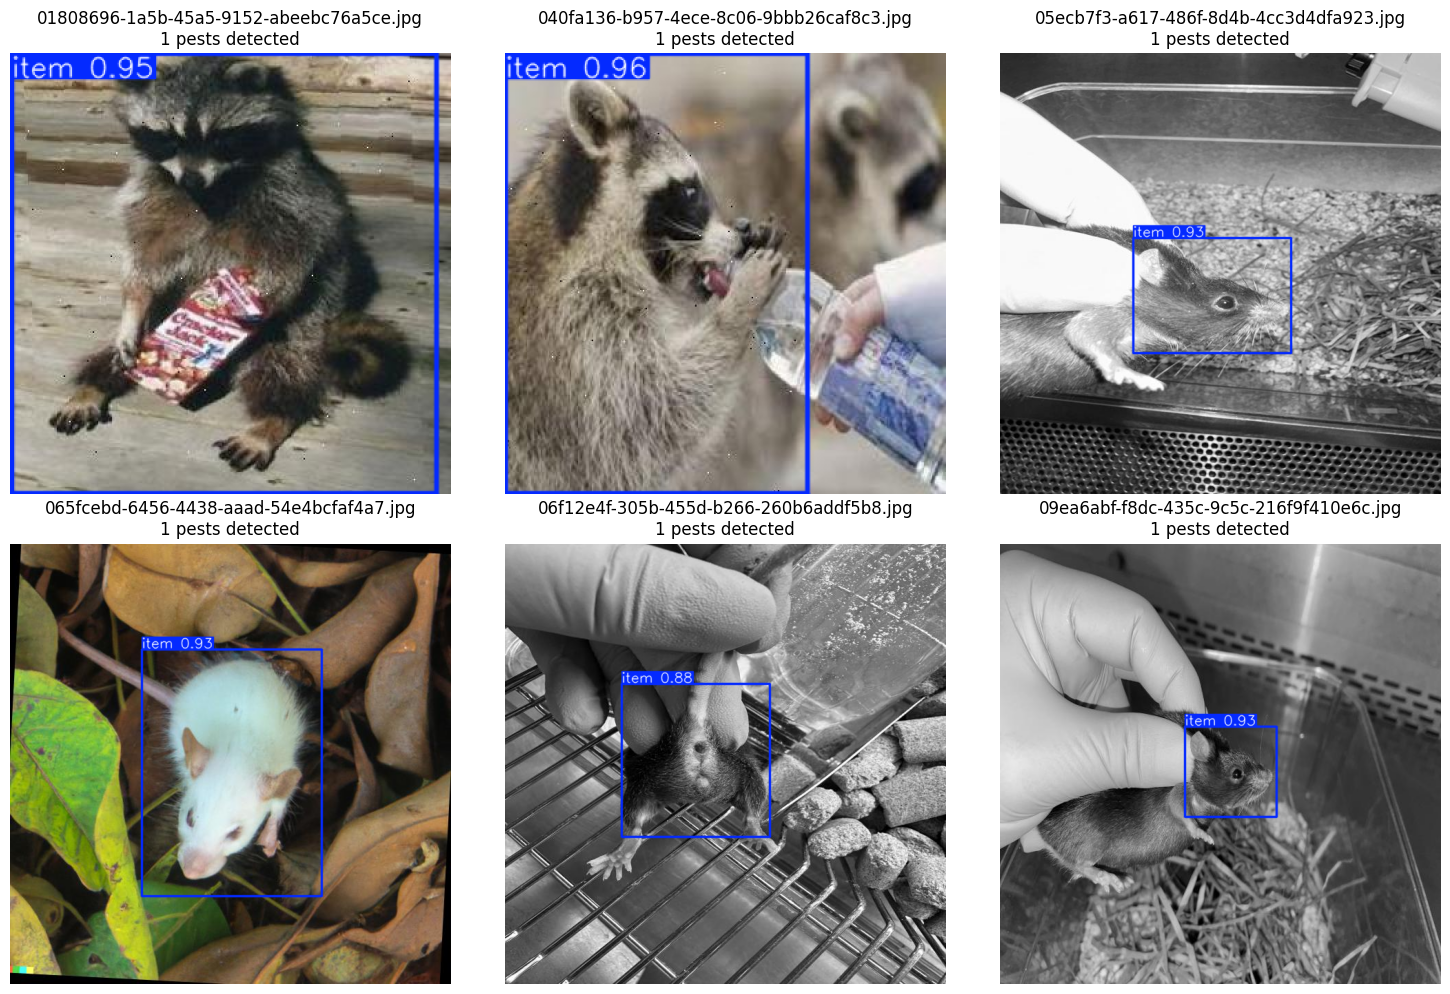

In [5]:
def visualize_sample_detections(num_samples=6):
    """Display sample detections with matplotlib"""
    
    test_images = [f for f in os.listdir(TEST_IMAGES_DIR) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Get samples with detections
    images_with_detections = []
    for img_name in test_images[:20]:  # Check first 20 for diversity
        img_path = os.path.join(TEST_IMAGES_DIR, img_name)
        results = model(img_path, conf=CONFIDENCE_THRESHOLD)
        if len(results[0].boxes) > 0:
            images_with_detections.append((img_name, results))
            if len(images_with_detections) >= num_samples:
                break
    
    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, (img_name, results) in enumerate(images_with_detections[:6]):
        # Convert BGR to RGB for matplotlib
        annotated_img = results[0].plot()
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(annotated_img_rgb)
        axes[idx].set_title(f'{img_name}\n{len(results[0].boxes)} pests detected')
        axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(images_with_detections), 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display sample detections
visualize_sample_detections()

In [6]:
def benchmark_performance():
    """Benchmark inference speed on test images"""
    
    test_images = [f for f in os.listdir(TEST_IMAGES_DIR) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    import time
    times = []
    
    print("⏱️  Benchmarking inference speed...")
    
    for img_name in test_images[:10]:  # Test on first 10 images
        img_path = os.path.join(TEST_IMAGES_DIR, img_name)
        
        start_time = time.time()
        results = model(img_path, conf=CONFIDENCE_THRESHOLD)
        end_time = time.time()
        
        inference_time = (end_time - start_time) * 1000  # Convert to milliseconds
        times.append(inference_time)
        
        print(f"   {img_name}: {inference_time:.1f}ms")
    
    print(f"\n📊 Performance Summary:")
    print(f"   Average inference time: {np.mean(times):.1f}ms")
    print(f"   FPS: {1000/np.mean(times):.1f}")
    print(f"   Min time: {np.min(times):.1f}ms")
    print(f"   Max time: {np.max(times):.1f}ms")

# Run benchmark
benchmark_performance()

⏱️  Benchmarking inference speed...

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\01808696-1a5b-45a5-9152-abeebc76a5ce.jpg: 640x640 1 item, 8.1ms
Speed: 2.1ms preprocess, 8.1ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)
   01808696-1a5b-45a5-9152-abeebc76a5ce.jpg: 18.4ms

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\040fa136-b957-4ece-8c06-9bbb26caf8c3.jpg: 640x640 1 item, 5.1ms
Speed: 1.9ms preprocess, 5.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
   040fa136-b957-4ece-8c06-9bbb26caf8c3.jpg: 10.3ms

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\05ecb7f3-a617-486f-8d4b-4cc3d4dfa923.jpg: 640x640 1 item, 3.7ms
Speed: 1.1ms preprocess, 3.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
   05ecb7f3-a617-486f-8d4b-4cc3d4dfa923.jpg: 8.5ms

image 1/1 c:\Users\plebj\Desktop\School\CS5814\augmentation_dataset\test\images\065fc